In [35]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [39]:
df = pd.read_csv("/content/dataset_with_all_features v2.csv")

df = df.rename(columns={'type': 'label'})

df = df.dropna(subset=['url', 'label'])

print(df.columns)
df.head()


Index(['url', 'label', 'label', 'web_is_live', 'web_security_score',
       'web_forms_count', 'web_password_fields', 'web_has_login',
       'web_ssl_valid', 'url_len', '@', '?', '-', '=', '.', '#', '%', '+', '$',
       '!', '*', ',', '//', 'digits', 'letters', 'domain', 'abnormal_url',
       'https', 'Shortining_Service', 'having_ip_address',
       'defac_has_hacked_terms', 'defac_has_suspicious_ext',
       'defac_path_depth', 'defac_is_deep_path', 'defac_path_underscores',
       'defac_is_gov_edu', 'defac_has_index_php', 'defac_has_option_param',
       'phish_has_brand', 'phish_brand_in_subdomain', 'phish_brand_in_path',
       'phish_hyphen_count', 'phish_digit_count', 'phish_long_domain',
       'phish_many_subdomains', 'phish_suspicious_tld', 'phish_keyword_count',
       'phish_has_redirect', 'phish_param_count', 'phish_encoded_chars',
       'enh_urgency_count', 'enh_security_count', 'enh_brand_count',
       'enh_brand_hijack', 'enh_subdomain_count', 'enh_long_path',
   

,url,label,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,...,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,...,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15


In [26]:
df = df.loc[:, ~df.columns.duplicated()]

if 'type' in df.columns:
    df = df.drop(columns=['label'], errors='ignore')
    df = df.rename(columns={'type': 'label'})

df['label'] = df['label'].astype(str).str.strip().str.lower()

df['label'] = df['label'].replace({
    'benign': 0,
    'phishing': 1,
    'malware': 1,
    'defacement': 1
})

df = df[df['label'].isin([0, 1])]

print(df['label'].value_counts())

/tmp/ipykernel_6868/2555000611.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({


label
0    428209
1    222910
Name: count, dtype: int64


In [30]:
X = df.drop(columns=['url', 'label', 'Date_inspection'], errors='ignore')

X = X.select_dtypes(include=[np.number])

y = df['label']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9762255805381497

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     85670
           1       0.98      0.95      0.96     44554

    accuracy                           0.98    130224
   macro avg       0.98      0.97      0.97    130224
weighted avg       0.98      0.98      0.98    130224



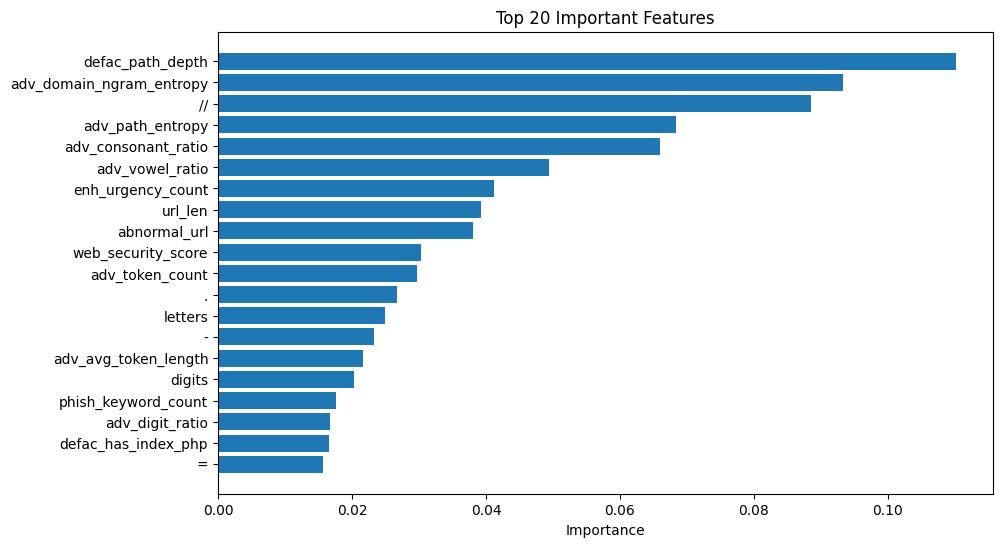

In [36]:
importances = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

In [37]:
def predict_sample(sample_row):
    sample = np.array(sample_row).reshape(1, -1)
    pred = model.predict(sample)[0]
    return "Malicious" if pred == 1 else "Safe"

In [40]:
sample = X.iloc[1].values
print("\nSample Prediction:", predict_sample(sample))


Sample Prediction: Safe


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
